# Capítulo 6: Series Temporales Financieras
## Ejercicio: Predicción de Retornos con Regresión Lineal

**Objetivo:** Descargar datos históricos de acciones (SPY), calcular retornos logarítmicos y crear un modelo autoregresivo (AR) para predecir el retorno futuro $r_t$ basado en el pasado.

$$ r_t = \beta_0 + \beta_1 r_{t-1} + \beta_2 r_{t-2} + \epsilon $$

In [3]:
import pandas as pd
import numpy as np
import yfinance as yf # pip install yfinance
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")

# Constantes del Ejercicio
TICKER = "SPY"       # ETF del S&P 500 (Representativo del mercado)
START_DATE = "2010-01-01"
END_DATE = "2023-12-31"

print("Librerías cargadas y configuración lista.")

Librerías cargadas y configuración lista.


Ingesta de Datos (Automática)
Utilizamos la API de Yahoo Finance para obtener datos diarios (OHLCV).

[*********************100%***********************]  1 of 1 completed

--> Descargando datos de SPY desde Yahoo Finance...
Nota: 'Adj Close' no encontrado, copiando 'Close'...
Éxito: Datos descargados. Dimensiones: 3522 días.
Columnas limpias: ['Close', 'High', 'Low', 'Open', 'Volume', 'Adj Close']


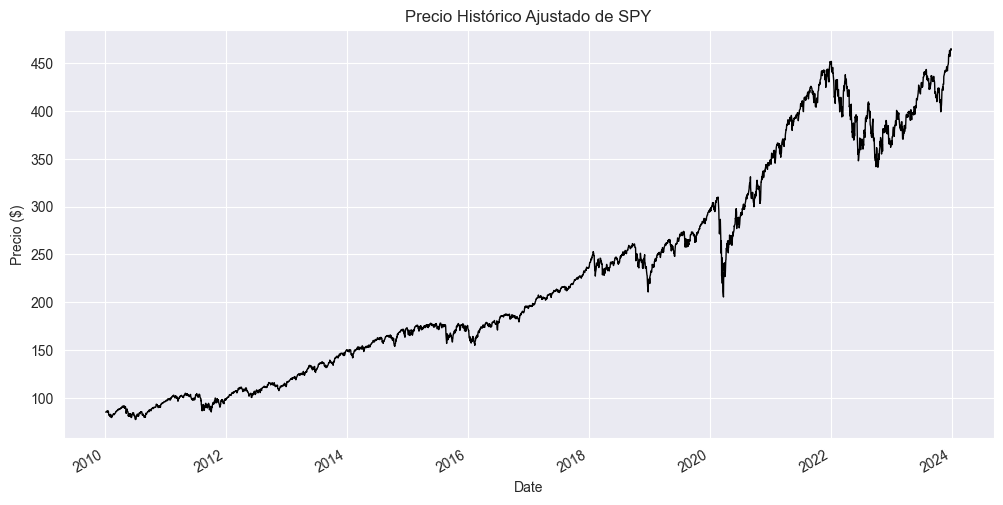

In [5]:
### 1. Ingesta de Datos (Automática)
print(f"--> Descargando datos de {TICKER} desde Yahoo Finance...")
df = yf.download(TICKER, start=START_DATE, end=END_DATE)

# --- CORRECCIÓN DE BUG YFINANCE ---
# Si las columnas son MultiIndex (ej: ('Adj Close', 'SPY')), nos quedamos solo con el nivel 0
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
# ----------------------------------

# Verificación de seguridad
if 'Adj Close' not in df.columns:
    # A veces yfinance entrega 'Close' ya ajustado y borra 'Adj Close'
    if 'Close' in df.columns:
        print("Nota: 'Adj Close' no encontrado, copiando 'Close'...")
        df['Adj Close'] = df['Close']
    else:
        print("ERROR CRÍTICO: No se encuentra columna de precio.")

print(f"Éxito: Datos descargados. Dimensiones: {df.shape[0]} días.")
print("Columnas limpias:", df.columns.tolist())

# Graficamos
plt.figure(figsize=(12, 6))
df['Adj Close'].plot(color='black', linewidth=1)
plt.title(f"Precio Histórico Ajustado de {TICKER}")
plt.ylabel("Precio ($)")
plt.show()

### 2. Ingeniería de Características: Retornos Logarítmicos (Precio y Volumen)

Siguiendo las instrucciones del ejercicio, calculamos los cambios logarítmicos no solo para el precio, sino también para el volumen de transacciones.

**Fórmulas:**
1. Retorno de Precio: $r_t^{price} = \log(P_t) - \log(P_{t-1})$
2. Cambio de Volumen: $r_t^{vol} = \log(V_t) - \log(V_{t-1})$

El uso de logaritmos en el volumen es crucial porque el volumen tiene una varianza enorme (picos explosivos) que necesita ser suavizada.

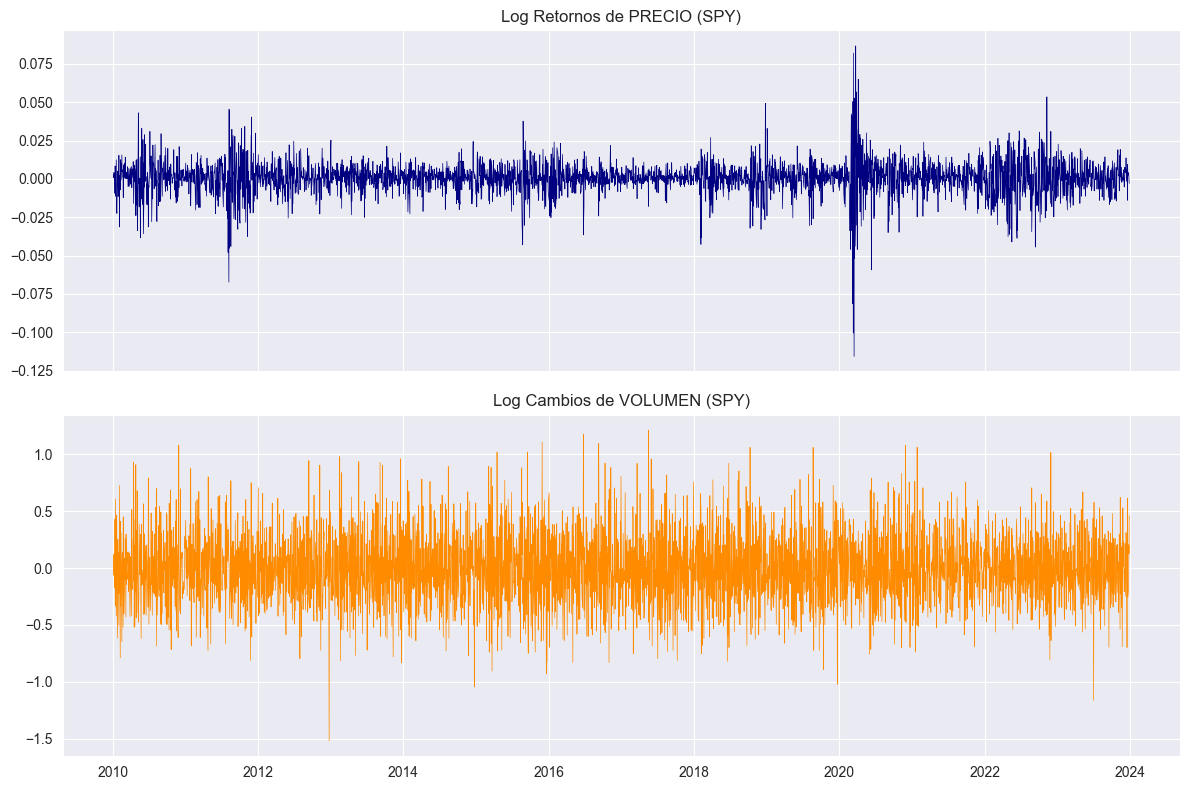

In [6]:
# 1. Log Returns del Precio
df['log_ret_price'] = np.log(df['Adj Close'] / df['Adj Close'].shift(1))

# 2. Log Returns del Volumen (Sumamos 1e-6 para evitar log(0))
df['log_ret_vol'] = np.log((df['Volume'] + 1e-6) / (df['Volume'].shift(1) + 1e-6))

# Limpieza inicial (los primeros datos son NaN por el shift)
df.dropna(inplace=True)

# Visualización Comparativa
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(df.index, df['log_ret_price'], color='navy', linewidth=0.5)
axes[0].set_title(f"Log Retornos de PRECIO ({TICKER})")
axes[1].plot(df.index, df['log_ret_vol'], color='darkorange', linewidth=0.5)
axes[1].set_title(f"Log Cambios de VOLUMEN ({TICKER})")
plt.tight_layout()
plt.show()

### 3. Feature Engineering Avanzado (Lags + Rolling Metrics)
Para mejorar la capacidad predictiva sin caer en overfitting, añadimos indicadores técnicos básicos:

1.  **Lags (Memoria a Corto Plazo):** $r_{t-1}, r_{t-2}$.
2.  **Tendencia Semanal (Rolling Mean):** Promedio de los últimos 5 días. Nos dice la dirección general.
3.  **Volatilidad (Rolling Std):** Desviación estándar de los últimos 5 días. Nos dice el "nerviosismo" del mercado.

**Nota:** Es crucial aplicar `.shift(1)` a las métricas rolling para no usar datos de hoy para predecir hoy (Data Leakage).

In [11]:
# --- Feature Engineering Avanzado ---

# 1. Lags (Lo que ya teníamos)
df['price_lag_1'] = df['log_ret_price'].shift(1)
df['price_lag_2'] = df['log_ret_price'].shift(2)

# 2. Tendencia (Promedio Móvil de 5 días)
# shift(1) es vital: queremos el promedio de AYER hacia atrás
df['trend_5'] = df['log_ret_price'].rolling(window=5).mean().shift(1)

# 3. Volatilidad (Desviación Estándar de 5 días)
df['vol_5'] = df['log_ret_price'].rolling(window=5).std().shift(1)

# Limpieza: Al usar rolling(5), los primeros 5 datos serán NaN.
df.dropna(inplace=True)

# Definimos la lista final de features para usarla después
FEATURES = ['price_lag_1', 'price_lag_2', 'trend_5', 'vol_5']
TARGET = 'log_ret_price'

print("Matriz de Diseño Actualizada:")
display(df[FEATURES + [TARGET]].head())

Matriz de Diseño Actualizada:


Price,price_lag_1,price_lag_2,trend_5,vol_5,log_ret_price
Date,,,,,
2010-01-14,0.008411,-0.009370,0.001594,0.006644,0.002701
2010-01-15,0.002701,0.008411,0.001292,0.006528,-0.011288
2010-01-19,-0.011288,0.002701,-0.001630,0.008395,0.012418
2010-01-20,0.012418,-0.011288,0.000574,0.010557,-0.010221
2010-01-21,-0.010221,0.012418,0.000404,0.010763,-0.019416


### 4. Análisis de Autocorrelación
Verificamos visualmente si el retorno de ayer predice el de hoy.

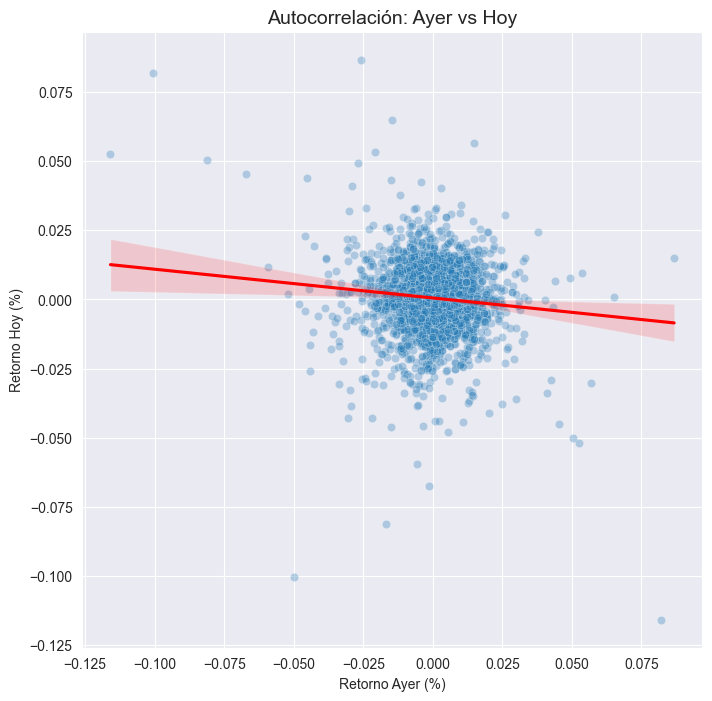

Correlación de Pearson: -0.1041


In [8]:
# Gráfico de dispersión: Ayer vs Hoy
plt.figure(figsize=(8, 8))
sns.scatterplot(x=df['price_lag_1'], y=df['log_ret_price'], alpha=0.3)
sns.regplot(x=df['price_lag_1'], y=df['log_ret_price'], scatter=False, color='red')

plt.title(f"Autocorrelación: Ayer vs Hoy", fontsize=14)
plt.xlabel("Retorno Ayer (%)")
plt.ylabel("Retorno Hoy (%)")
plt.show()

# Correlación numérica
corr = df['log_ret_price'].corr(df['price_lag_1'])
print(f"Correlación de Pearson: {corr:.4f}")

### 5.Modelado Robusto: Ridge Regression ($L_2$)
En lugar de una Regresión Lineal simple (OLS), utilizamos **Ridge Regression**.

Este método añade un término de penalización a la función de coste:
$$ J(\beta) = \text{MSE} + \alpha \sum \beta_i^2 $$

Esto evita que el modelo asigne coeficientes exagerados a variables ruidosas, reduciendo la varianza y el overfitting.

In [12]:
from sklearn.linear_model import Ridge # <--- Importante
from sklearn.metrics import mean_squared_error

# 1. Split Cronológico (80% Train, 20% Test)
train_size = int(len(df) * 0.8)
train_data = df.iloc[:train_size].copy()
test_data = df.iloc[train_size:].copy()

X_train, y_train = train_data[FEATURES], train_data[TARGET]
X_test, y_test = test_data[FEATURES], test_data[TARGET]

print(f"Train: {len(X_train)} días | Test: {len(X_test)} días")

# 2. Entrenamiento con Regularización
# alpha=0.5 es un valor moderado. (Mayor alpha = Más regularización/Modelo más plano)
model = Ridge(alpha=0.5)
model.fit(X_train, y_train)

# 3. Análisis de Coeficientes (Interpretación Quant)
print(f"\n--- Coeficientes del Modelo Ridge ---")
print(f"Intercepto: {model.intercept_:.6f}")
for feature, coef in zip(FEATURES, model.coef_):
    print(f"Beta ({feature}): {coef:.6f}")

# 4. Predicción y Evaluación
test_data['prediction'] = model.predict(X_test)
mse = mean_squared_error(y_test, test_data['prediction'])
print(f"\nMSE en Test: {mse:.6f}")

Train: 2811 días | Test: 703 días

--- Coeficientes del Modelo Ridge ---
Intercepto: 0.000572
Beta (price_lag_1): -0.051045
Beta (price_lag_2): 0.035732
Beta (trend_5): -0.011855
Beta (vol_5): -0.004630

MSE en Test: 0.000125


### 6. Backtesting (Simulación de Estrategia)
Evaluamos si el modelo genera valor económico.
Comparamos dos curvas de capital acumulado (P&L):

1.  **Buy & Hold (Benchmark):** Comprar SPY y no hacer nada.
2.  **Estrategia AR(2):**
    *   Si $\hat{r}_t > 0$: Compramos (Ganamos el retorno del mercado).
    *   Si $\hat{r}_t < 0$: Vendemos/Cash (Ganancia 0 ese día).

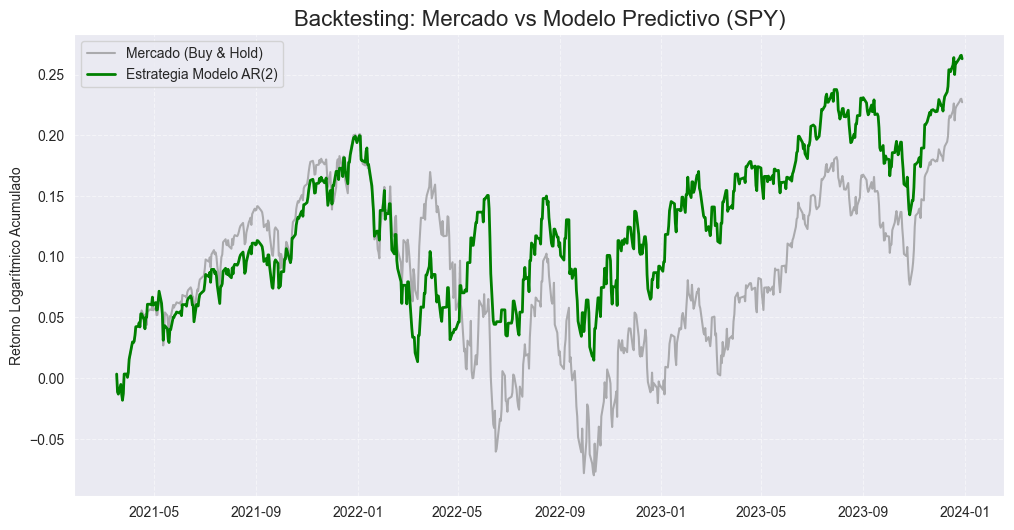

Retorno Total Mercado: 22.72%
Retorno Total Estrategia: 26.30%
CONCLUSIÓN: ¡El modelo batió al mercado! (En teoría)


In [13]:
# 1. Lógica de Trading (Vectorizada)
# np.where(condición, valor_si_true, valor_si_false)
# Si predecimos subida, tomamos el retorno real del mercado. Si no, nos quedamos en 0 (Cash).
test_data['strategy_return'] = np.where(test_data['prediction'] > 0, 
                                        test_data['log_ret_price'], 
                                        0)

# 2. Cálculo de Retornos Acumulados (Suma acumulativa de Log Returns)
test_data['cum_market'] = test_data['log_ret_price'].cumsum()
test_data['cum_strategy'] = test_data['strategy_return'].cumsum()

# 3. Visualización de Resultados (La Hora de la Verdad)
plt.figure(figsize=(12, 6))
plt.plot(test_data.index, test_data['cum_market'], label='Mercado (Buy & Hold)', color='gray', alpha=0.6)
plt.plot(test_data.index, test_data['cum_strategy'], label='Estrategia Modelo AR(2)', color='green', linewidth=2)

plt.title(f"Backtesting: Mercado vs Modelo Predictivo ({TICKER})", fontsize=16)
plt.ylabel("Retorno Logarítmico Acumulado")
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

# Resultado Final
total_market = test_data['cum_market'].iloc[-1]
total_strategy = test_data['cum_strategy'].iloc[-1]

print(f"Retorno Total Mercado: {total_market:.2%}")
print(f"Retorno Total Estrategia: {total_strategy:.2%}")

if total_strategy > total_market:
    print("CONCLUSIÓN: ¡El modelo batió al mercado! (En teoría)")
else:
    print("CONCLUSIÓN: El modelo no superó al simple Buy & Hold (Mercado eficiente).")